Solo run a run

In [2]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Run Configuration

In [163]:
RUN_ID = 16047          # 16057

SELECTION_CRITERIA = {  'Ar': [ ("Multiplicities", lambda x: (x['nS1'].sum() == 1) & (x['nS2'].sum() == 1))
                              , ("S1 Width"      , lambda x: (0      <= x['S1w'].sum() <= 4.5e3 ))    # In [ns]
                              # , ("S1 Energy"     , lambda x: (750    <= x['S1e'].sum() <= 1500  ))    # In [PE]
                              , ("S1 Time"       , lambda x: (1000e3 <= x['S1t'].sum()          ))    # In [ns]
                              , ("S2 Width"      , lambda x: (0      <= x['S2w'].sum() <= 250   ))    # In [μs]
                              , ("S2 Time"       , lambda x: (          x['S2t'].sum() <= 1650e3))    # In [ns]
                              ],  
                             
                        'Xe': []}

## Reconstructed Data

In [164]:
doro_dict = crudo.dm.load_run_data(RUN_ID, id=True, trigger=None)
doro_df = doro_dict[RUN_ID]
print(f"\n{doro_df.head()}\n")

cath_stop = crudo.tf.cathode_position(RUN_ID, doro_dict, id=True, step_back=1)

Z_mask = {RUN_ID: ( (doro_df['DT'] >= 0) 
                  & (doro_df['DT'] <  cath_stop[RUN_ID]) )}

/DST/Events: Run 16047 successfully loaded with data shape: (12989, 26)

   event          time  s1_peak  s2_peak  nS1  nS2     S1w        S1h  \
0      8  1.784798e+09        0        0    1    1  2375.0  18.987965   
1     15  1.784798e+09        0        0    1    1   825.0  13.149719   
2     36  1.784798e+09        0        0    1    1  1925.0  14.803468   
3     50  1.784798e+09        0        0    2    1  1550.0  12.302834   
4     50  1.784798e+09        1        0    2    1  1325.0  14.589763   

          S1e        S1t  ...  Nsipm          DT           Z       Zrms  \
0  212.182114  1075200.0  ...     21  528.738403  528.738403  10.045424   
1  110.090683  1236075.0  ...     23  366.947388  366.947388   4.929298   
2  170.682922  1077725.0  ...     29  526.287415  526.287415   7.704215   
3  117.687424  1459350.0  ...     23  253.709259  253.709259   5.425862   
4  138.471695  1565300.0  ...     23  147.759262  147.759262   5.425862   

            X           Y           R

# Base Distributions (NO CUTS!)

## Radial

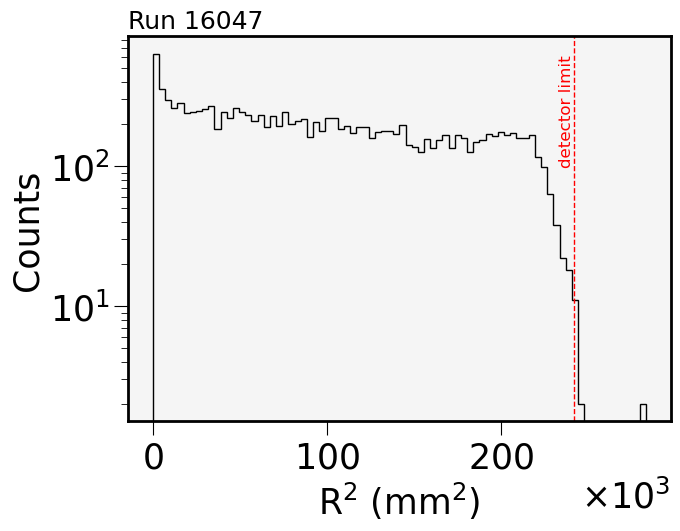

In [165]:
# Variables
R2 = doro_df['X']**2 + doro_df['Y']**2

# Histogram
counts, bins, _ = plt.hist(R2, bins=80, histtype='step', color='black', lw=1.0)

# Plot
plt.xlabel('R$^{2}$ (mm$^{2}$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='left', fontsize=18)
# Radial line
plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--', lw=1)
plt.text(crudo.pt.N100_rad**2, counts[0], 'detector limit', c='red', va='top',  ha='right',  rotation=90, fontsize=12)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## ΔT

Run 16047: Cathode position = (521.82 ± 15.15) μs
Run 16047: No negative DT values found.


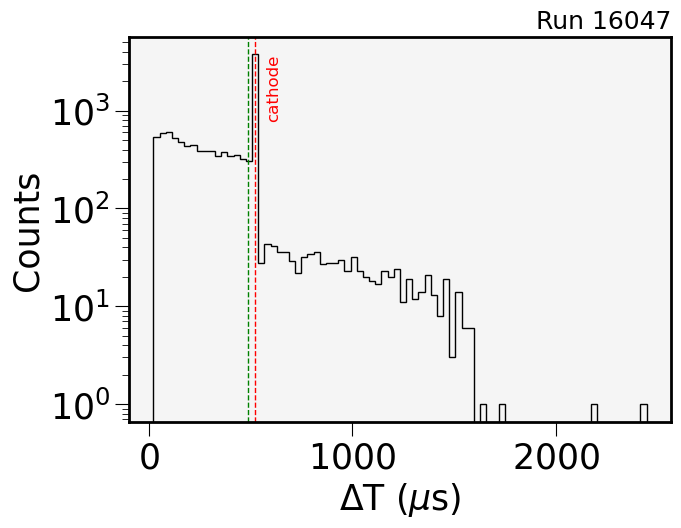

In [166]:
# Variables
DT = doro_df['DT']

# Histogram
counts, bins, _ = plt.hist(DT, bins=80, histtype='step', color='black', lw=1.0)

# Estimated cathode time position + error
cath_index   = np.argmax(counts)    # Index of the bin with the highest count
cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
cath_error   = (bins[1] - bins[0]) / 2
print(f"Run {RUN_ID}: Cathode position = ({cath_central:.2f} ± {cath_error:.2f}) μs")

# Negative DT's?
negative_DT = doro_df[DT < 0]    
if not negative_DT.empty:
    print(f"Run {RUN_ID}: There are {len(negative_DT)} negative DT values.")
else:
    print(f"Run {RUN_ID}: No negative DT values found.")

# Plot
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cathode line
plt.axvline(x=cath_central, c='red', ls='--', lw=1)
plt.text(1.1*cath_central, counts[cath_index], 'cathode', c='red', va='top',  ha='left',  rotation=90, fontsize=12)
plt.axvline(x=cath_stop[RUN_ID], c='green', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## $S1$ Pulse

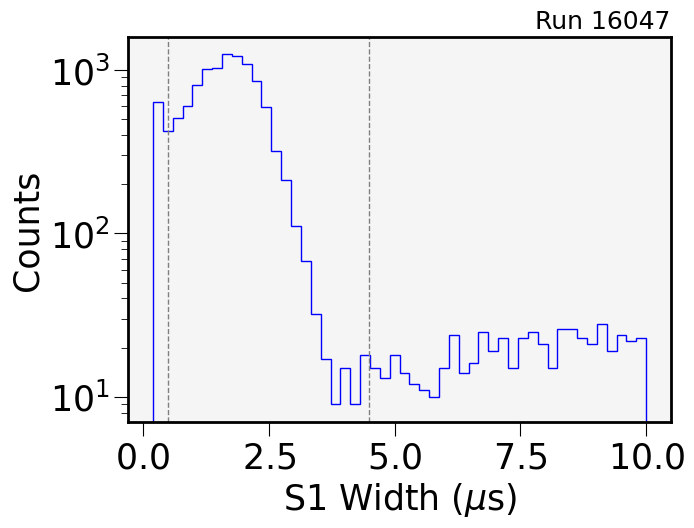

In [167]:
# Variables
W1 = doro_df['S1w'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(W1, bins=50, range=None, histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Width ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=0.5, c='gray', ls='--', lw=1)
plt.axvline(x=4.5, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

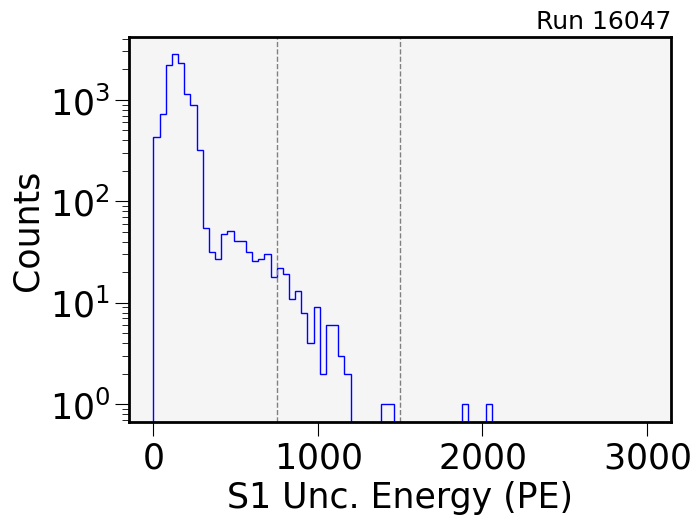

In [168]:
# Variables
E1 = doro_df['S1e']

# Histogram
counts, bins, _ = plt.hist(E1, bins=80, range=(0, 3e3), histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Unc. Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=750, c='gray', ls='--', lw=1)
plt.axvline(x=1500, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

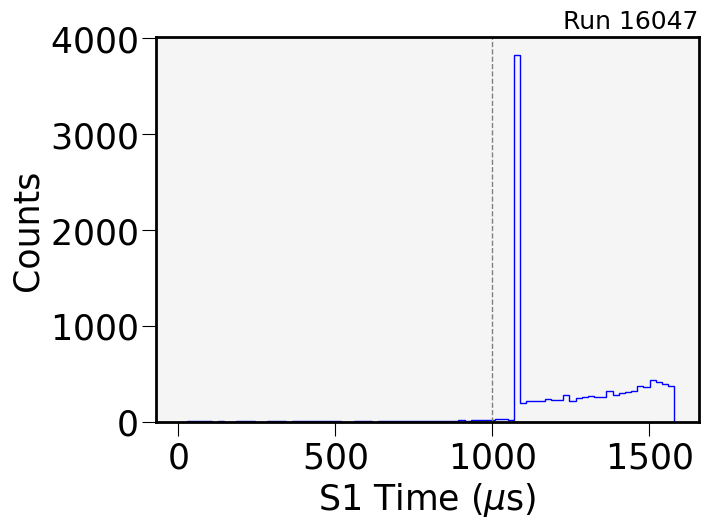

In [169]:
# Variables
T1 = doro_df['S1t'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(T1, bins=80, histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Time ($\mu$s)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=1000, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## $S2$ Pulse

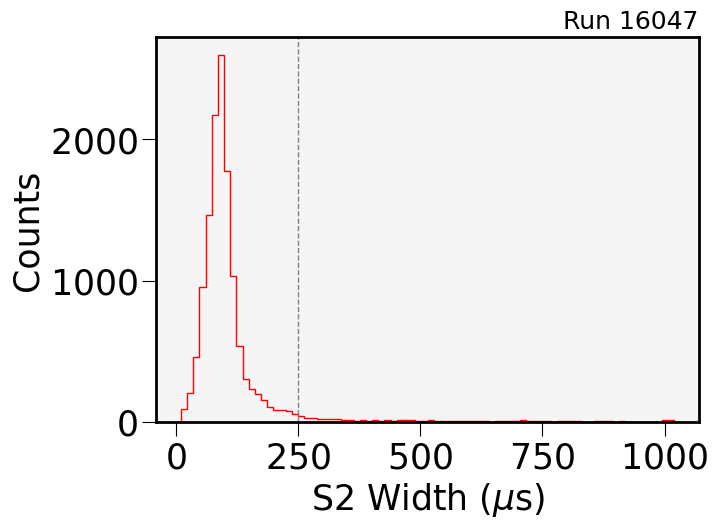

In [170]:
# Variables
W2 = doro_df['S2w']

# Histogram
counts, bins, _ = plt.hist(W2, bins=80, histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Width ($\mu$s)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
# plt.axvline(x=35, c='gray', ls='--', lw=1)
plt.axvline(x=250, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

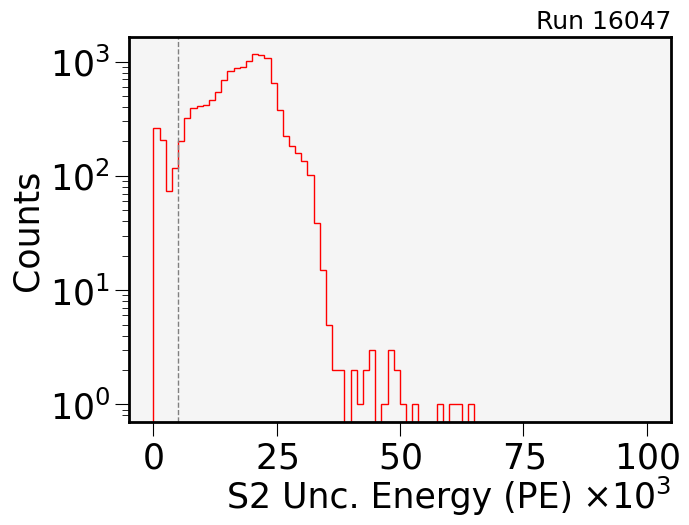

In [171]:
# Variables
E2 = doro_df['S2e']

# Histogram
counts, bins, _ = plt.hist(E2, bins=80, range=(0, 100e3), histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Unc. Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=5e3, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

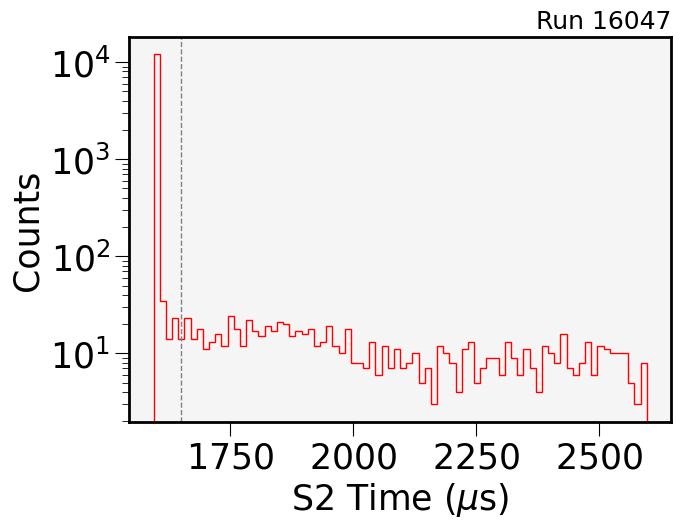

In [172]:
# Variables
T2 = doro_df['S2t'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(T2, bins=80, histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Time ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=1650, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

# Selection

In [173]:
# Total number of events
total_events = doro_df['event'].nunique()

print(f"Run {RUN_ID} - Selection Efficiency:")
print(f"  Initially: {total_events} events")

# Start with full dataset
temp_df = doro_df.copy()

# Apply each cut step by step
for label, condition in SELECTION_CRITERIA['Ar']:

    temp_df = temp_df.groupby('event').filter(condition)
    rem_events  = temp_df['event'].nunique()
    
    print(f"  After {label}: {rem_events} events ({(rem_events / total_events) * 100:.2f}%)")

# Store final selected data
sel_df = temp_df.copy()

Run 16047 - Selection Efficiency:
  Initially: 11585 events
  After Multiplicities: 8918 events (76.98%)
  After S1 Width: 8871 events (76.57%)
  After S1 Time: 8862 events (76.50%)
  After S2 Width: 8619 events (74.40%)
  After S2 Time: 8406 events (72.56%)


In [100]:
doro_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
0,1,1.784902e+09,0,0,1,1,1775.0,12.254223,139.169785,1410350.0,...,13,190.759384,190.759384,5.733649,427.149912,-175.647231,461.853870,-0.390130,12.266569,11.461667
1,15,1.784902e+09,65535,0,0,1,NaN,NaN,NaN,NaN,...,9,NaN,NaN,5.796145,-223.514487,-409.570683,466.590688,-2.070354,10.346894,86.604741
2,36,1.784902e+09,0,0,1,1,1850.0,25.345480,267.978455,1077125.0,...,31,526.835022,526.835022,5.961503,341.740249,-18.549117,342.243287,-0.054225,75.718297,48.382228
3,50,1.784903e+09,0,0,1,1,1050.0,7.066187,71.358490,1418200.0,...,20,183.806259,183.806259,7.004291,-220.403302,149.380136,266.255592,2.545951,17.022547,29.606881
4,64,1.784903e+09,0,0,1,1,1625.0,16.176067,159.484039,1077300.0,...,26,525.643921,525.643921,5.751606,-229.856437,-101.433200,251.242265,-2.726006,86.666698,68.489103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39003,51478,1.784980e+09,0,0,1,1,2600.0,19.280996,269.585663,1078875.0,...,41,526.133545,526.133545,7.485401,15.933331,-61.947621,63.963887,-1.319047,49.385691,62.888176
39004,51492,1.784980e+09,0,0,1,1,1550.0,11.456813,120.261925,1514600.0,...,26,88.356750,88.356750,6.022161,298.059483,-98.430954,313.891874,-0.318963,63.387049,21.469780
39005,51499,1.784980e+09,0,0,1,1,1150.0,8.228826,80.603394,1323875.0,...,201,279.134277,279.134277,10.010409,-14.208160,111.252913,112.156509,1.697819,197.030525,228.144996
39006,51506,1.784980e+09,0,0,1,1,925.0,16.858528,138.908539,1102225.0,...,33,501.712769,501.712769,5.671770,-67.831106,358.853332,365.207849,1.757614,73.075755,124.586958


In [111]:
sel_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
0,1,1.784902e+09,0,0,1,1,1775.0,12.254223,139.169785,1410350.0,...,13,190.759384,190.759384,5.733649,427.149912,-175.647231,461.853870,-0.390130,12.266569,11.461667
2,36,1.784902e+09,0,0,1,1,1850.0,25.345480,267.978455,1077125.0,...,31,526.835022,526.835022,5.961503,341.740249,-18.549117,342.243287,-0.054225,75.718297,48.382228
3,50,1.784903e+09,0,0,1,1,1050.0,7.066187,71.358490,1418200.0,...,20,183.806259,183.806259,7.004291,-220.403302,149.380136,266.255592,2.545951,17.022547,29.606881
4,64,1.784903e+09,0,0,1,1,1625.0,16.176067,159.484039,1077300.0,...,26,525.643921,525.643921,5.751606,-229.856437,-101.433200,251.242265,-2.726006,86.666698,68.489103
5,71,1.784903e+09,0,0,1,1,925.0,10.359735,107.850975,1437775.0,...,26,165.195389,165.195389,6.059923,27.851011,404.112769,405.071363,1.501986,73.506270,134.900009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39003,51478,1.784980e+09,0,0,1,1,2600.0,19.280996,269.585663,1078875.0,...,41,526.133545,526.133545,7.485401,15.933331,-61.947621,63.963887,-1.319047,49.385691,62.888176
39004,51492,1.784980e+09,0,0,1,1,1550.0,11.456813,120.261925,1514600.0,...,26,88.356750,88.356750,6.022161,298.059483,-98.430954,313.891874,-0.318963,63.387049,21.469780
39005,51499,1.784980e+09,0,0,1,1,1150.0,8.228826,80.603394,1323875.0,...,201,279.134277,279.134277,10.010409,-14.208160,111.252913,112.156509,1.697819,197.030525,228.144996
39006,51506,1.784980e+09,0,0,1,1,925.0,16.858528,138.908539,1102225.0,...,33,501.712769,501.712769,5.671770,-67.831106,358.853332,365.207849,1.757614,73.075755,124.586958


# Base Distributions (WITH CUTS!)

## Radial

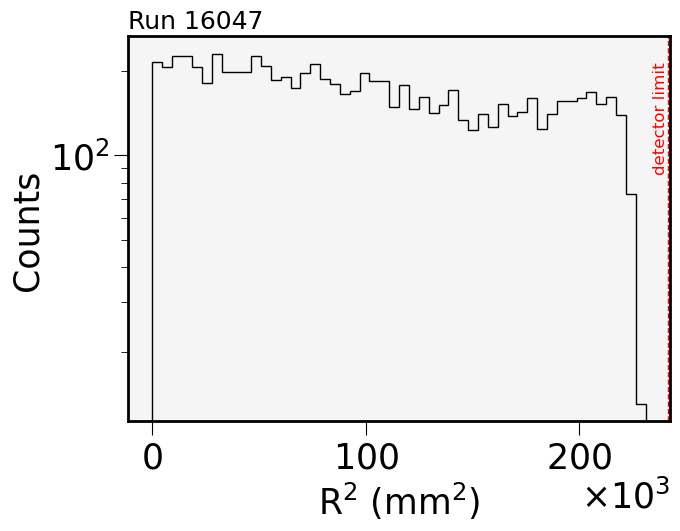

In [174]:
# Variables
R2 = sel_df['X']**2 + sel_df['Y']**2

# Histogram
counts, bins, _ = plt.hist(R2, bins=50, histtype='step', color='black', lw=1.0)

# Plot
plt.xlabel('R$^{2}$ (mm$^{2}$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='left', fontsize=18)
# Radial line
plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--', lw=1)
plt.text(crudo.pt.N100_rad**2, counts[0], 'detector limit', c='red', va='top',  ha='right',  rotation=90, fontsize=12)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## ΔT

Run 16047: Cathode position = (525.25 ± 5.65) μs
Run 16047: No negative DT values found.


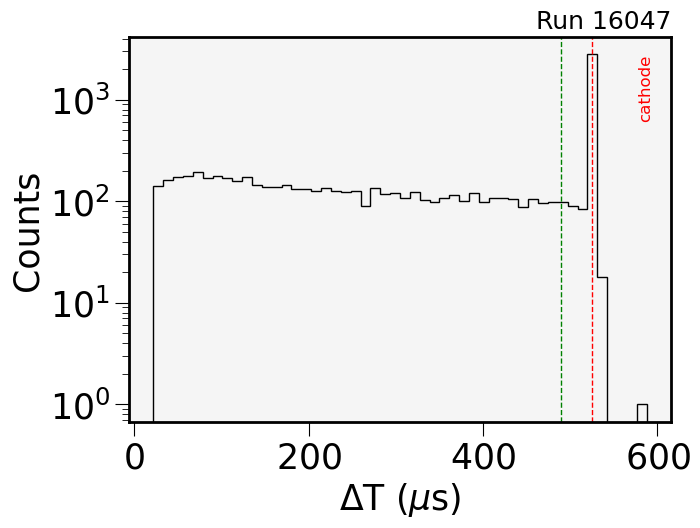

In [175]:
# Variables
DT = sel_df['DT']

# Histogram
counts, bins, _ = plt.hist(DT, bins=50, histtype='step', color='black', lw=1.0)

# Estimated cathode time position + error
cath_index   = np.argmax(counts)    # Index of the bin with the highest count
cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
cath_error   = (bins[1] - bins[0]) / 2
print(f"Run {RUN_ID}: Cathode position = ({cath_central:.2f} ± {cath_error:.2f}) μs")

# Negative DT's?
negative_DT = sel_df[DT < 0]    
if not negative_DT.empty:
    print(f"Run {RUN_ID}: There are {len(negative_DT)} negative DT values.")
else:
    print(f"Run {RUN_ID}: No negative DT values found.")

# Plot
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cathode line
plt.axvline(x=cath_central, c='red', ls='--', lw=1)
plt.text(1.1*cath_central, counts[cath_index], 'cathode', c='red', va='top',  ha='left',  rotation=90, fontsize=12)
plt.axvline(x=cath_stop[RUN_ID], c='green', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## $S1$ Pulse

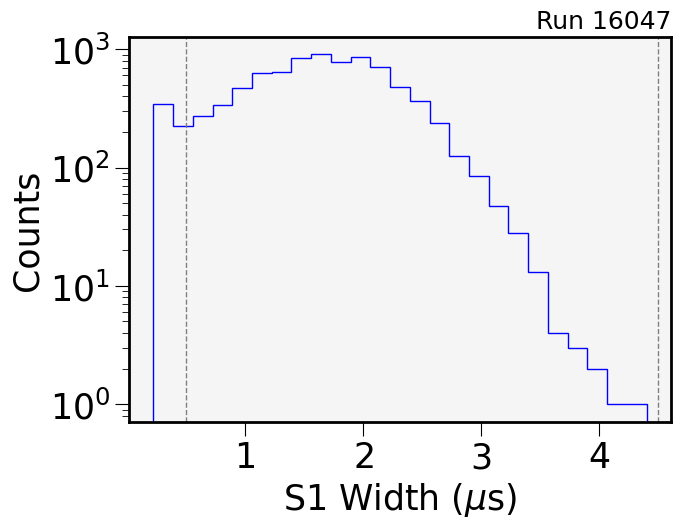

In [176]:
# Variables
W1 = sel_df['S1w'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(W1, bins=25, range=None, histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Width ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=0.5, c='gray', ls='--', lw=1)
plt.axvline(x=4.5, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

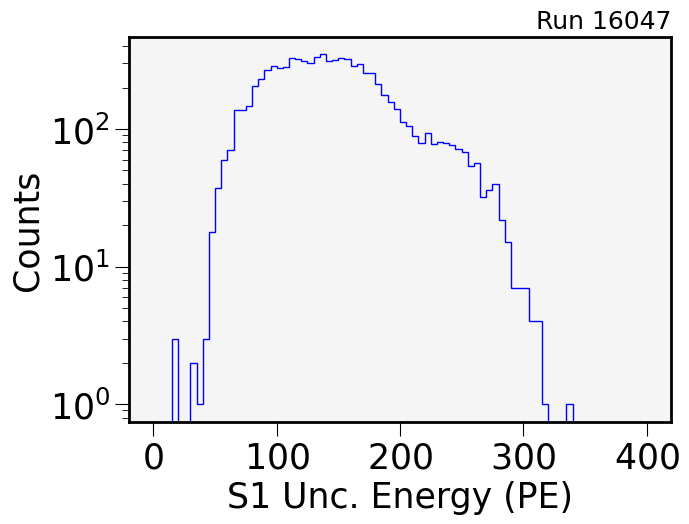

In [177]:
# Variables
E1 = sel_df['S1e']

# Histogram
counts, bins, _ = plt.hist(E1, bins=80, range=(0, 0.4e3), histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Unc. Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
# plt.axvline(x=750, c='gray', ls='--', lw=1)
# plt.axvline(x=1500, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

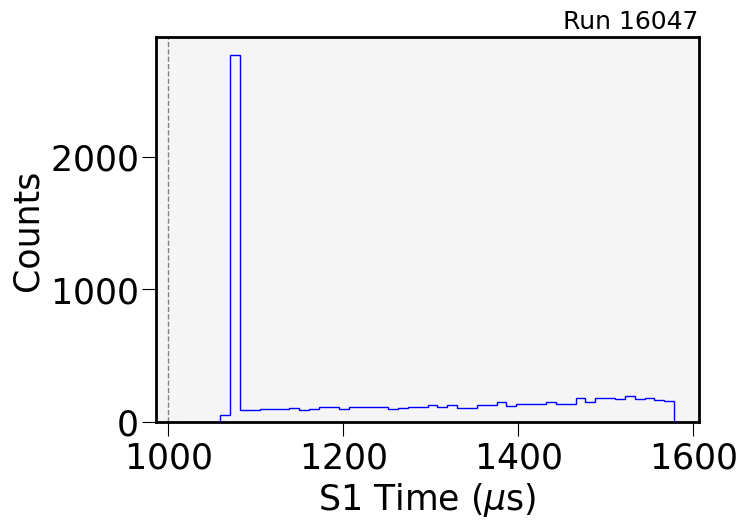

In [178]:
# Variables
T1 = sel_df['S1t'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(T1, bins=50, histtype='step', color='blue', lw=1.0)

# Plot
plt.xlabel('S1 Time ($\mu$s)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=1000, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

## $S2$ Pulse

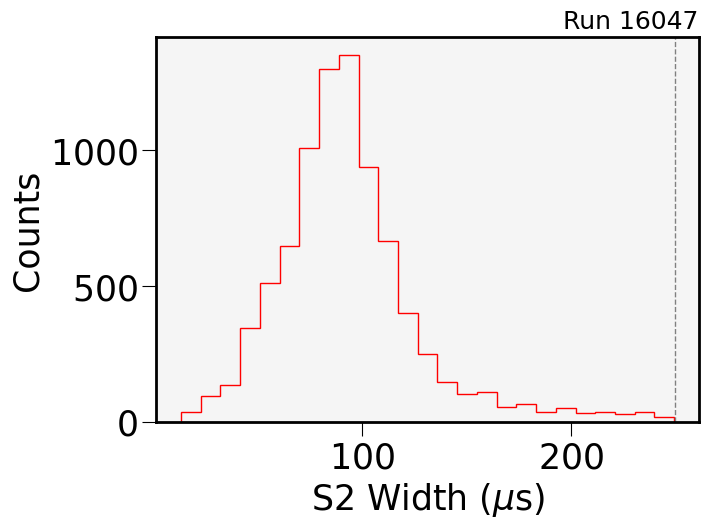

In [179]:
# Variables
W2 = sel_df['S2w']

# Histogram
counts, bins, _ = plt.hist(W2, bins=25, histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Width ($\mu$s)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
# plt.axvline(x=35, c='gray', ls='--', lw=1)
plt.axvline(x=250, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

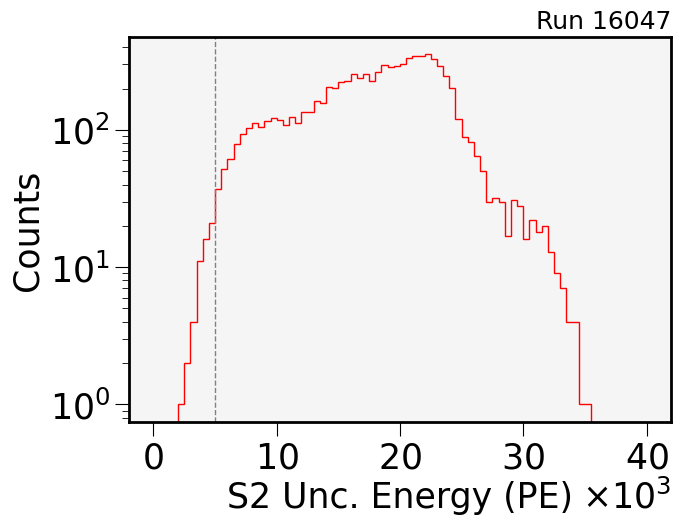

In [180]:
# Variables
E2 = sel_df['S2e']

# Histogram
counts, bins, _ = plt.hist(E2, bins=80, range=(0, 40e3), histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Unc. Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=5e3, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

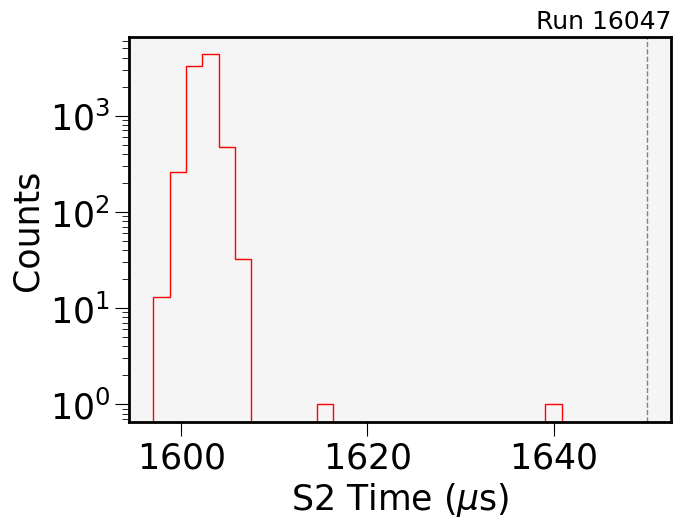

In [181]:
# Variables
T2 = sel_df['S2t'] / 1e3   # [μs]

# Histogram
counts, bins, _ = plt.hist(T2, bins=25, histtype='step', color='red', lw=1.0)

# Plot
plt.xlabel('S2 Time ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.title(f'Run {RUN_ID}', loc='right', fontsize=18)
# Cut line
plt.axvline(x=1650, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

# Control Plots

## Maps

### Event

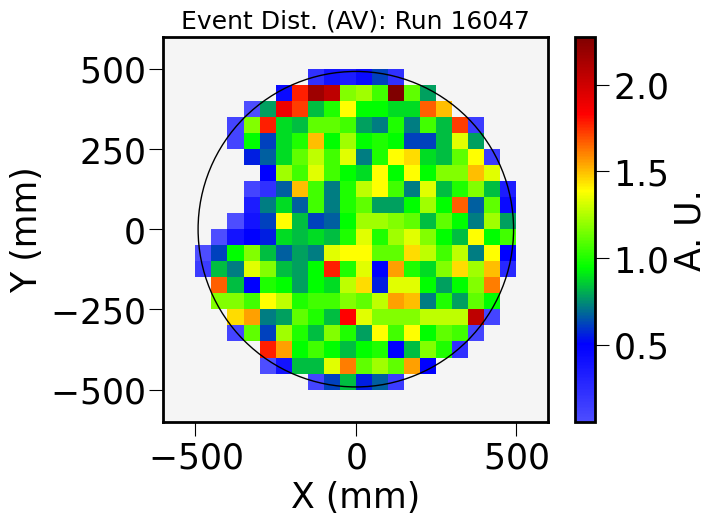

In [182]:
# Variables    
X = sel_df['X']
Y = sel_df['Y']

# Masking
mask = (Z_mask[RUN_ID])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, xy_bins=25, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Event Dist. (AV): Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Energy

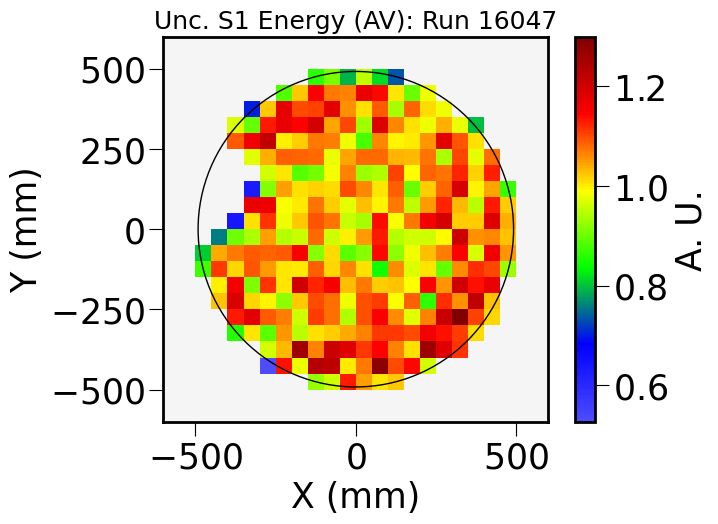

In [184]:
# Variables    
X = sel_df['X']
Y = sel_df['Y']
E1 = sel_df['S1e']

# Masking
mask = (Z_mask[RUN_ID])
X_mask = X[mask]
Y_mask = Y[mask]
E1_mask = E1[mask]

# Map
s1e_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=E1_mask, xy_bins=25, norm=True)
s1e_map         = np.ma.masked_where(s1e_map==0, s1e_map)
s1e_map         = np.clip(s1e_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, s1e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Unc. S1 Energy (AV): Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

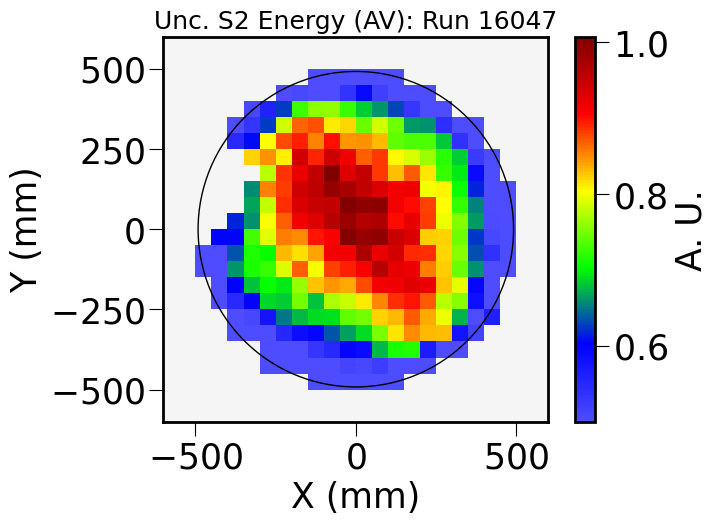

In [185]:
# Variables    
X = sel_df['X']
Y = sel_df['Y']
E2 = sel_df['S2e']

# Masking
mask = (Z_mask[RUN_ID])
X_mask = X[mask]
Y_mask = Y[mask]
E2_mask = E2[mask]

# Map
s2e_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=E2_mask, xy_bins=25, norm=True)
s2e_map         = np.ma.masked_where(s2e_map==0, s2e_map)
s2e_map         = np.clip(s2e_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, s2e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Unc. S2 Energy (AV): Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Width

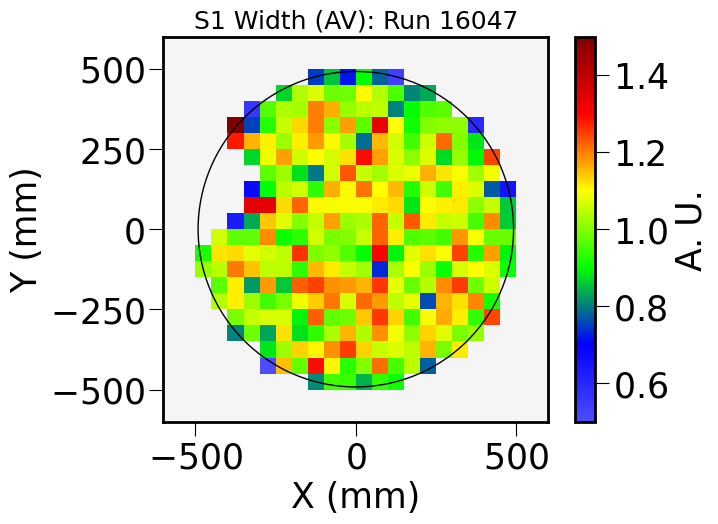

In [186]:
# Variables    
X = sel_df['X']
Y = sel_df['Y']
W1 = sel_df['S1w']

# Masking
mask = (Z_mask[RUN_ID])
X_mask = X[mask]
Y_mask = Y[mask]
W1_mask = W1[mask]

# Map
s1w_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=W1_mask, xy_bins=25, norm=True)
s1w_map         = np.ma.masked_where(s1w_map==0, s1w_map)
s1w_map         = np.clip(s1w_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, s1w_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'S1 Width (AV): Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

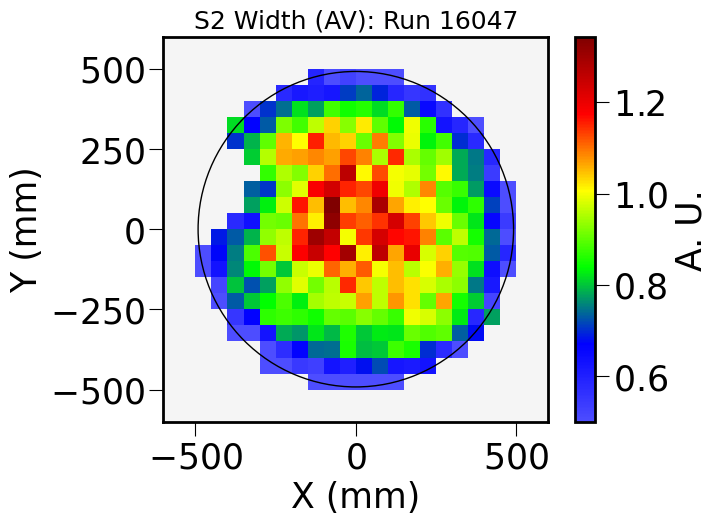

In [187]:
# Variables    
X = sel_df['X']
Y = sel_df['Y']
W2 = sel_df['S2w']

# Masking
mask = (Z_mask[RUN_ID])
X_mask = X[mask]
Y_mask = Y[mask]
W2_mask = W2[mask]

# Map
s2w_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, wei=W2_mask, xy_bins=25, norm=True)
s2w_map         = np.ma.masked_where(s2w_map==0, s2w_map)
s2w_map         = np.clip(s2w_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, s2w_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'S2 Width (AV): Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

## 2D Histograms

### Energy

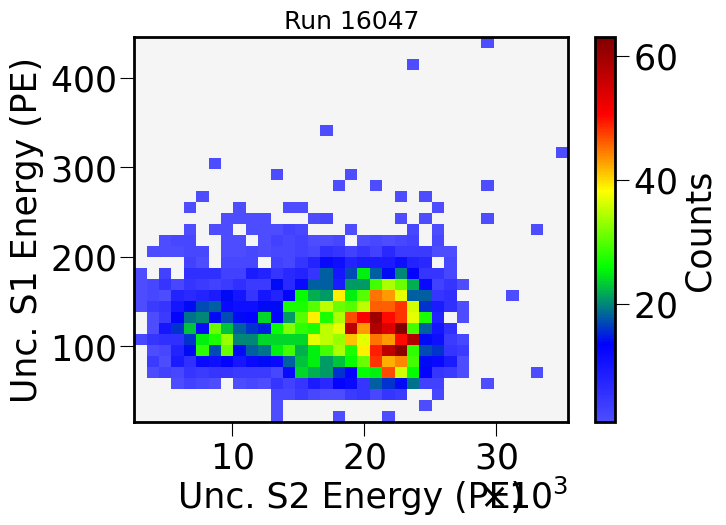

In [188]:
# Variables    
E1 = sel_df['S1e']
E2 = sel_df['S2e']
R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

# Masking
mask = (Z_mask[RUN_ID]) & (R <= 500)
E1_mask = E1[mask]
E2_mask = E2[mask]

# 2D Histogram
s1e_s2e_map, ex, ey = np.histogram2d(E2_mask, E1_mask, bins=[35, 35])
s1e_s2e_map         = np.ma.masked_where(s1e_s2e_map==0, s1e_s2e_map)

# Plot
plt.pcolormesh(ex, ey, s1e_s2e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='Counts')
plt.xlabel('Unc. S2 Energy (PE)')
plt.ylabel('Unc. S1 Energy (PE)')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.title (f'Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().set_facecolor("whitesmoke")
plt.show()

### Light Collection

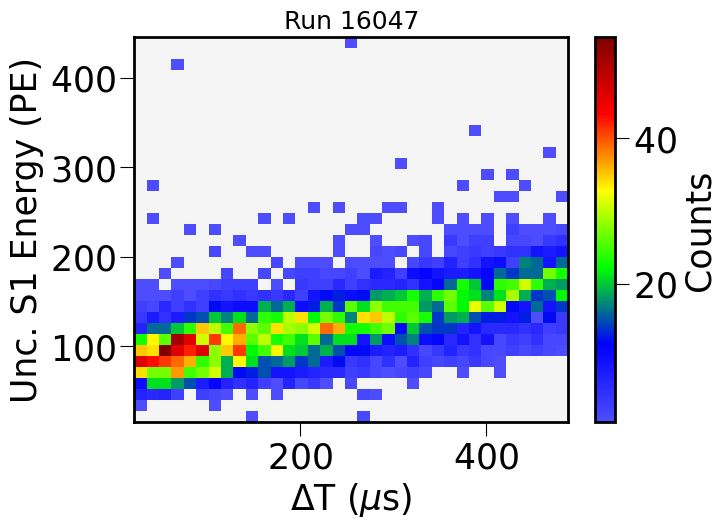

In [189]:
# Variables    
E1 = sel_df['S1e']
DT = sel_df['DT']
R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

# Masking
mask = (Z_mask[RUN_ID]) & (R <= 500)
E1_mask = E1[mask]
DT_mask = DT[mask]

# 2D Histogram
s1e_dt_map, ex, ey = np.histogram2d(DT_mask, E1_mask, bins=[35, 35])
s1e_dt_map         = np.ma.masked_where(s1e_dt_map==0, s1e_dt_map)

# Plot
plt.pcolormesh(ex, ey, s1e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='Counts')
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Unc. S1 Energy (PE)')
plt.title (f'Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().set_facecolor("whitesmoke")
plt.show()

### Lifetime

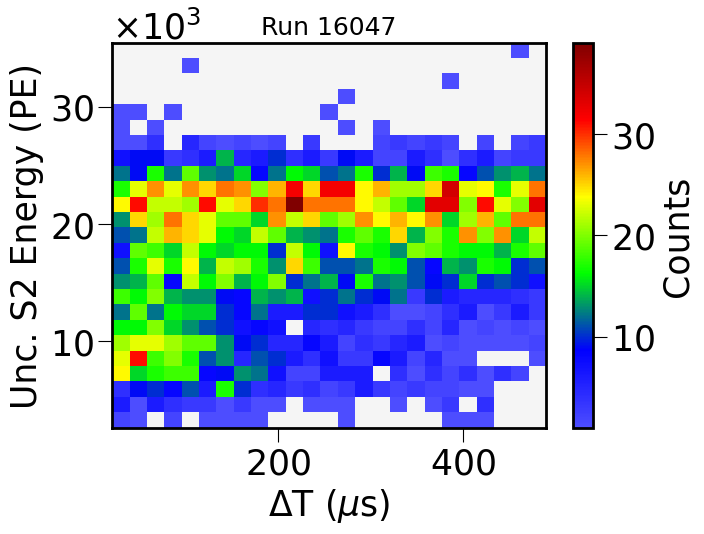

In [190]:
# Variables    
E2 = sel_df['S2e']
DT = sel_df['DT']
R = np.sqrt(sel_df['X']**2 + sel_df['Y']**2)

# Masking
mask = (Z_mask[RUN_ID]) & (R <= 500)
E2_mask = E2[mask]
DT_mask = DT[mask]

# 2D Histogram
s2e_dt_map, ex, ey = np.histogram2d(DT_mask, E2_mask, bins=[25, 25])
s2e_dt_map         = np.ma.masked_where(s2e_dt_map==0, s2e_dt_map)

# Plot
plt.pcolormesh(ex, ey, s2e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='Counts')
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Unc. S2 Energy (PE)')
plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
plt.title (f'Run {RUN_ID}', loc='center', fontsize=18) 

plt.gca().set_facecolor("whitesmoke")
plt.show()